In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df=pd.read_csv('/content/ai_workforce_displacement_global_2020_2026.csv')

In [ ]:
df.head()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...


In [ ]:
df.isnull().sum()

,0
record_id,0
country,0
iso3_code,0
region,0
income_group,0
year,0
quarter,0
quarter_label,0
industry_sector,0
sector_automation_risk_score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               20800 non-null  int64  
 1   country                                 20800 non-null  object 
 2   iso3_code                               20800 non-null  object 
 3   region                                  20800 non-null  object 
 4   income_group                            20800 non-null  object 
 5   year                                    20800 non-null  int64  
 6   quarter                                 20800 non-null  int64  
 7   quarter_label                           20800 non-null  object 
 8   industry_sector                         20800 non-null  object 
 9   sector_automation_risk_score            20800 non-null  float64
 10  gdp_per_capita_usd                      20800 non-null  in

In [ ]:
df.columns

Index(['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year',
       'quarter', 'quarter_label', 'industry_sector',
       'sector_automation_risk_score', 'gdp_per_capita_usd',
       'ai_adoption_index', 'pct_sector_workforce_displaced',
       'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
       'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct',
       'pct_workforce_female', 'pct_displaced_roles_female',
       'reskilling_programs_count', 'govt_ai_policy_score_1_to_10',
       'ai_tool_adoption_pct', 'data_source_notes'],
      dtype='object')

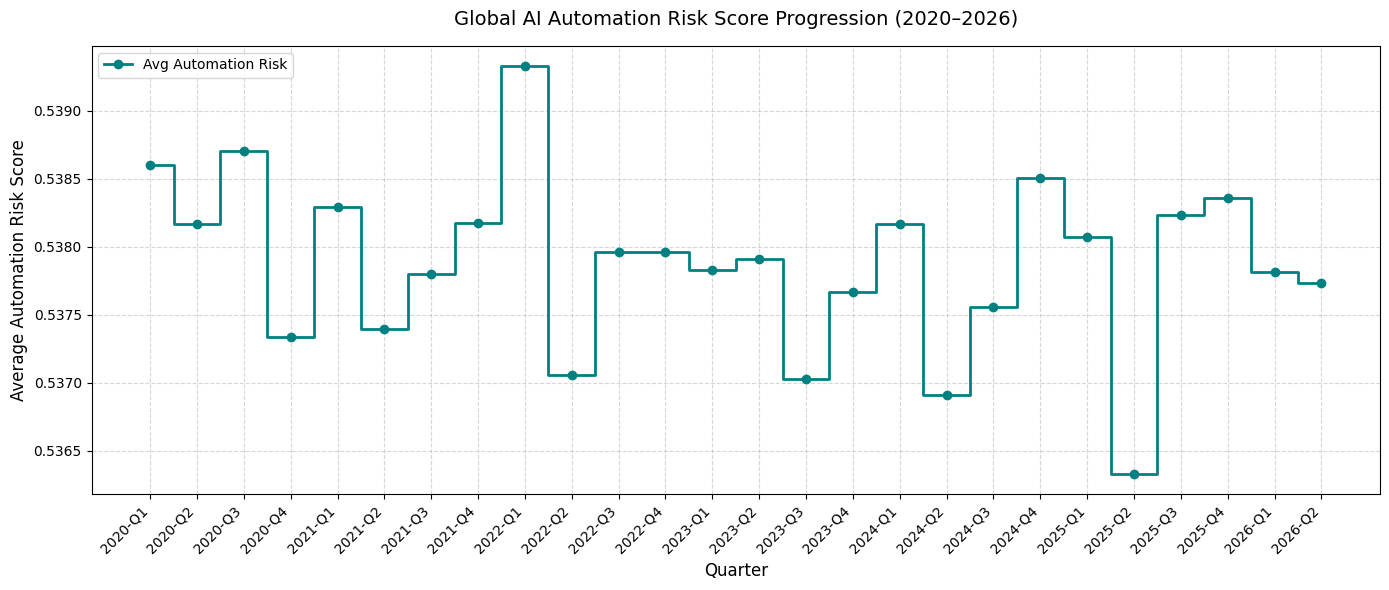

In [ ]:
#step graph
import matplotlib.pyplot as plt
import pandas as pd

# 1. Group the data by quarter and calculate the average score
# (You can replace 'sector_automation_risk_score' with any other numerical metric in your dataset)
trend_data = df.groupby('quarter_label')['sector_automation_risk_score'].mean().reset_index()

# 2. Ensure the quarter labels are sorted chronologically
trend_data['quarter_label'] = pd.Categorical(trend_data['quarter_label'], ordered=True)
trend_data = trend_data.sort_values('quarter_label')

# 3. Create the step plot
plt.figure(figsize=(14, 6))

# 'where' parameter controls where the step occurs ('pre', 'post', or 'mid')
plt.step(trend_data['quarter_label'], trend_data['sector_automation_risk_score'],
         where='mid', color='teal', linewidth=2, marker='o', label='Avg Automation Risk')

# Formatting the graph
plt.title('Global AI Automation Risk Score Progression (2020–2026)', fontsize=14, pad=15)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Automation Risk Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5007/262274909.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['industry_sector', 'quarter_label'])['sector_automation_risk_score'].mean().reset_index()


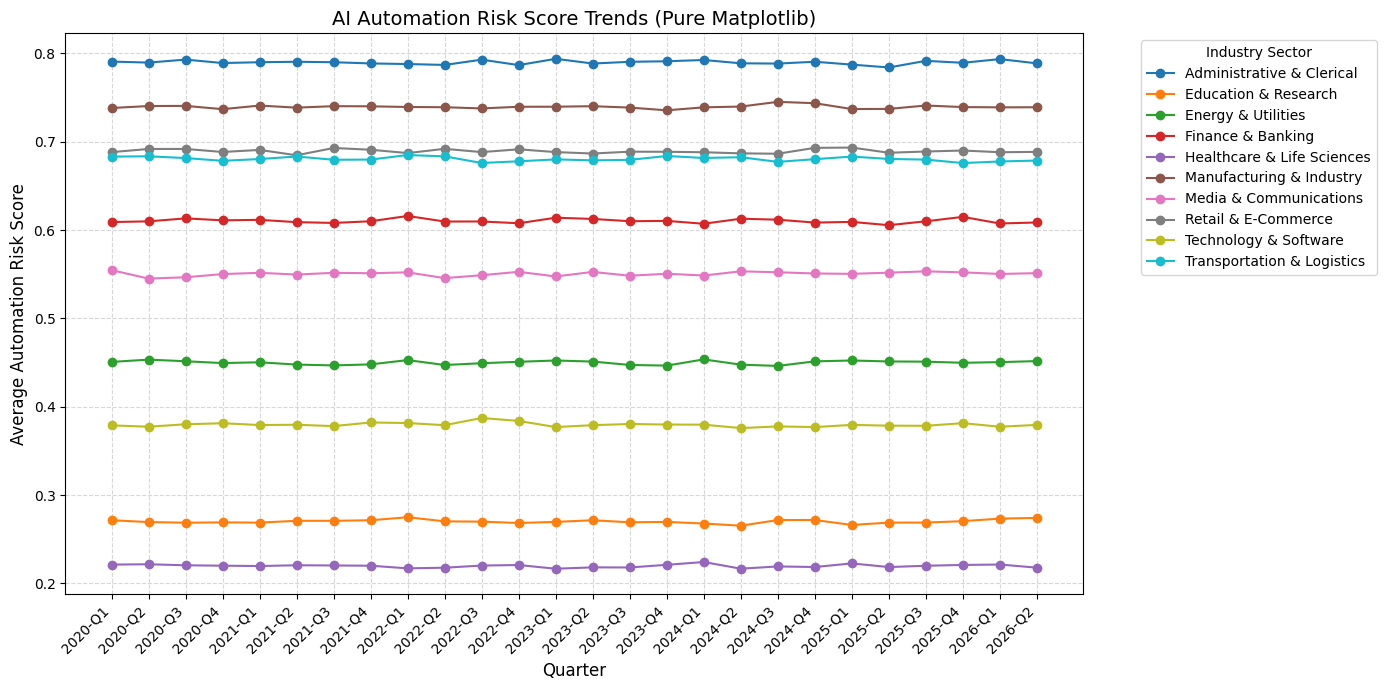

In [ ]:
# 1. Group by sector and quarter, then calculate the mean
grouped = df.groupby(['industry_sector', 'quarter_label'])['sector_automation_risk_score'].mean().reset_index()

plt.figure(figsize=(14, 7))

# 2. Loop through each unique sector and plot its line
for sector, group in grouped.groupby('industry_sector'):
    # Sort each group chronologically just to be safe
    group = group.sort_values('quarter_label')
    plt.plot(group['quarter_label'], group['sector_automation_risk_score'], marker='o', label=sector)

# Formatting
plt.title('AI Automation Risk Score Trends (Pure Matplotlib)', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Automation Risk Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

# Place legend outside
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5007/173565996.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  area_data = df.pivot_table(


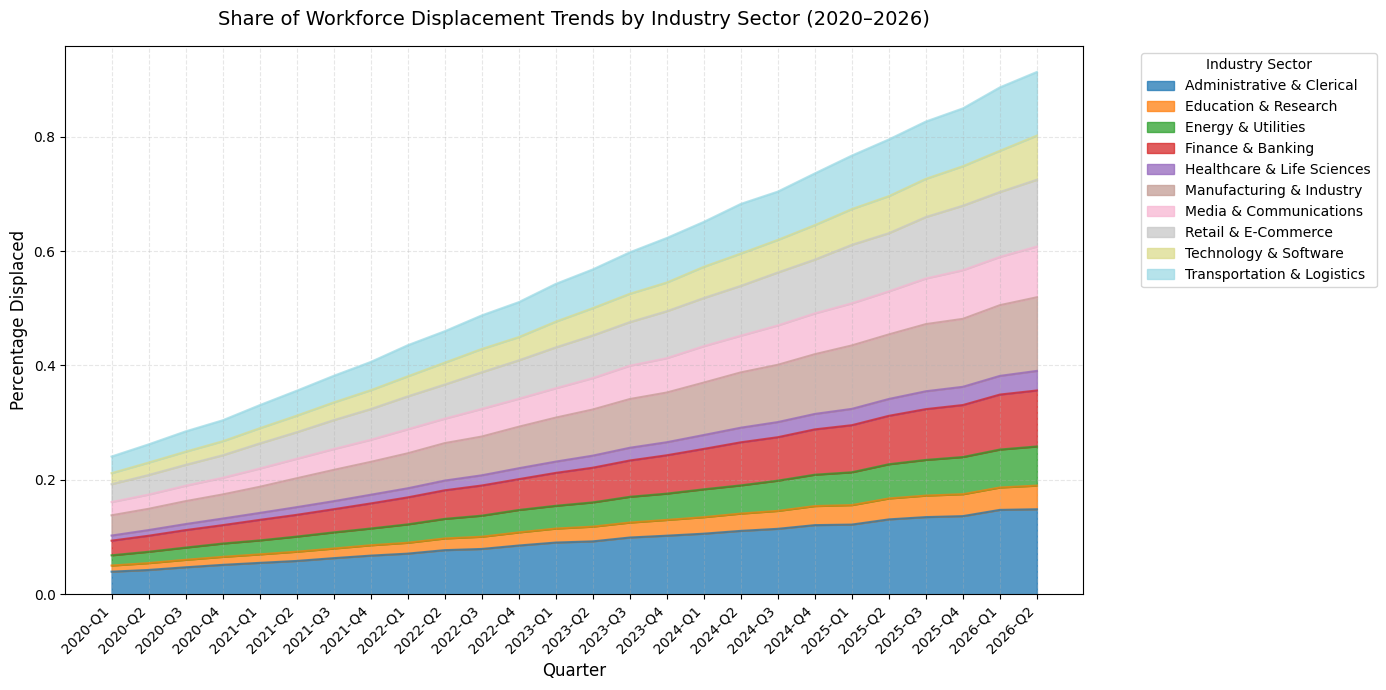

In [ ]:

# 1. Pivot the data to get quarters as rows and industry sectors as columns
# (Using 'pct_sector_workforce_displaced' as an example metric)
area_data = df.pivot_table(
    index='quarter_label',
    columns='industry_sector',
    values='pct_sector_workforce_displaced',
    aggfunc='mean'
).fillna(0)

# 2. Ensure chronological sorting
area_data.index = pd.Categorical(area_data.index, ordered=True)
area_data = area_data.sort_index()

# 3. Plot the stacked area chart
fig, ax = plt.subplots(figsize=(14, 7))
area_data.plot.area(ax=ax, alpha=0.75, colormap='tab20')

# Formatting
plt.title('Share of Workforce Displacement Trends by Industry Sector (2020–2026)', fontsize=14, pad=15)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Percentage Displaced', fontsize=12)
plt.xticks(range(len(area_data.index)), area_data.index, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

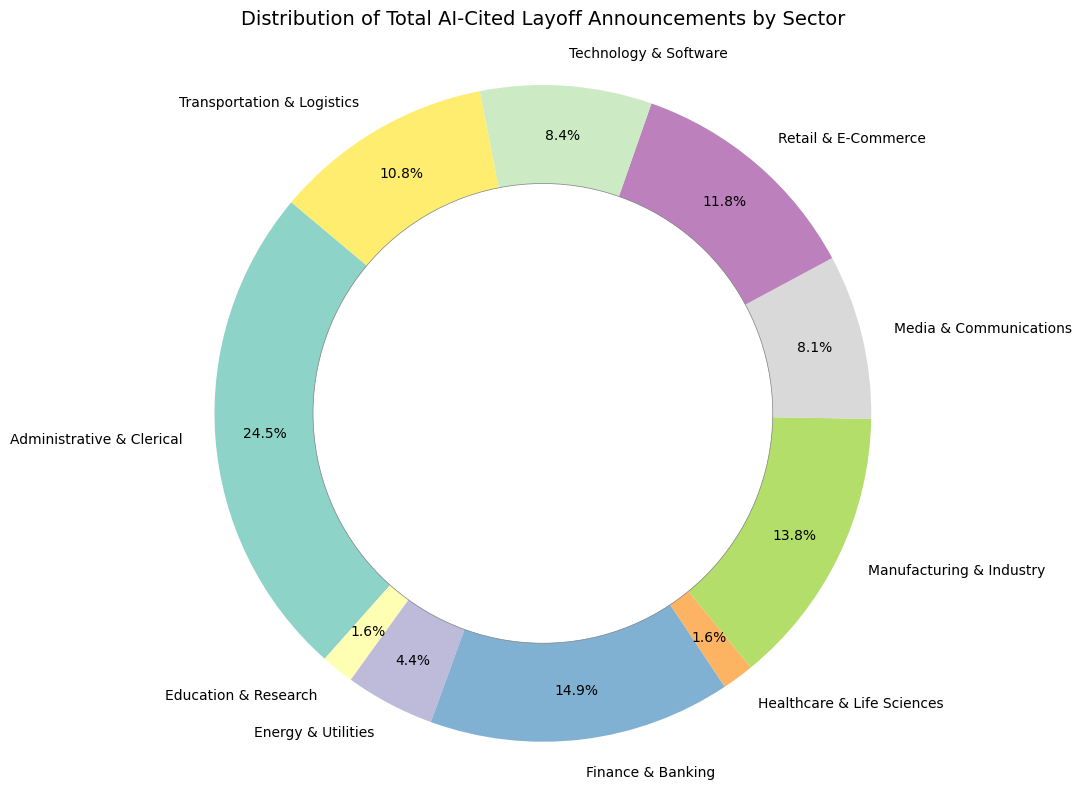

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

# 1. Aggregate total AI-cited layoffs by Industry Sector
# (Filtering out any sectors with 0 or negligible layoffs to keep the chart clean)
doughnut_data = df.groupby('industry_sector')['ai_cited_layoff_announcements'].sum().reset_index()
doughnut_data = doughnut_data[doughnut_data['ai_cited_layoff_announcements'] > 0]

labels = doughnut_data['industry_sector']
sizes = doughnut_data['ai_cited_layoff_announcements']

# Generate colors from the 'Set3' colormap
colors = cm.Set3(np.linspace(0, 1, len(labels)))

# 2. Plotting the Chart
plt.figure(figsize=(10, 8))

# Create the base pie chart
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=colors  # Use the generated colors
)

# 3. Draw a central white circle to create the "doughnut" hole
centre_circle = plt.Circle((0,0), 0.70, fc='white', edgecolor='gray', linewidth=0.5)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Formatting
plt.title('Distribution of Total AI-Cited Layoff Announcements by Sector', fontsize=14, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

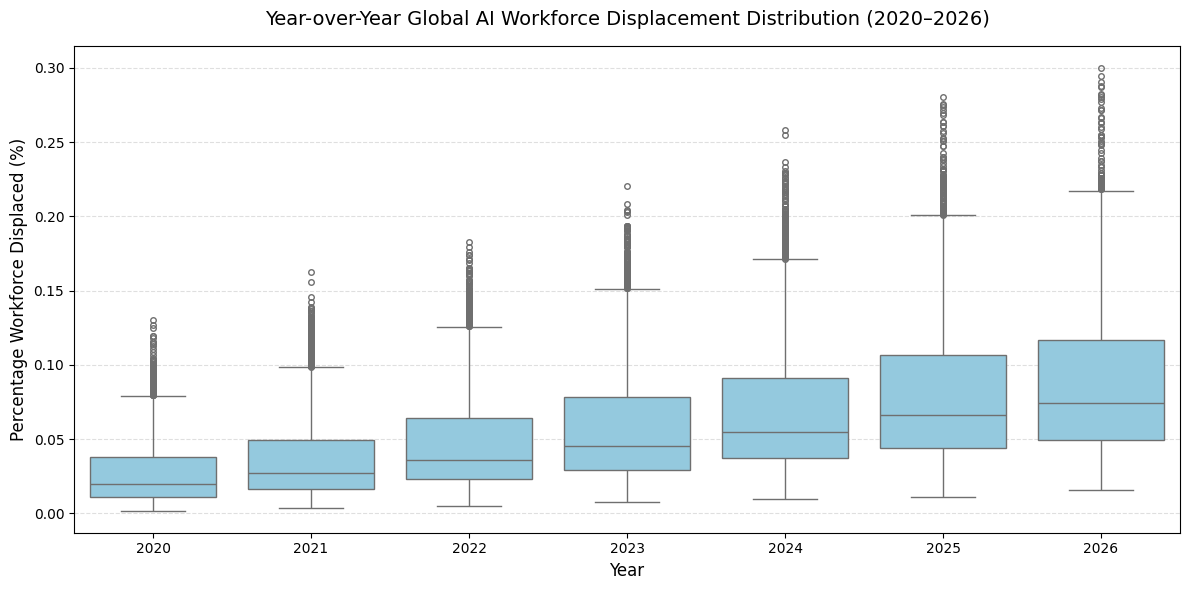

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Draw vertical boxplot over the years tracking workforce displacement %
sns.boxplot(
    data=df,
    x='year',
    y='pct_sector_workforce_displaced',
    color='skyblue',
    fliersize=4 # Controls the size of the outlier points
)

# Formatting
plt.title('Year-over-Year Global AI Workforce Displacement Distribution (2020–2026)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage Workforce Displaced (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

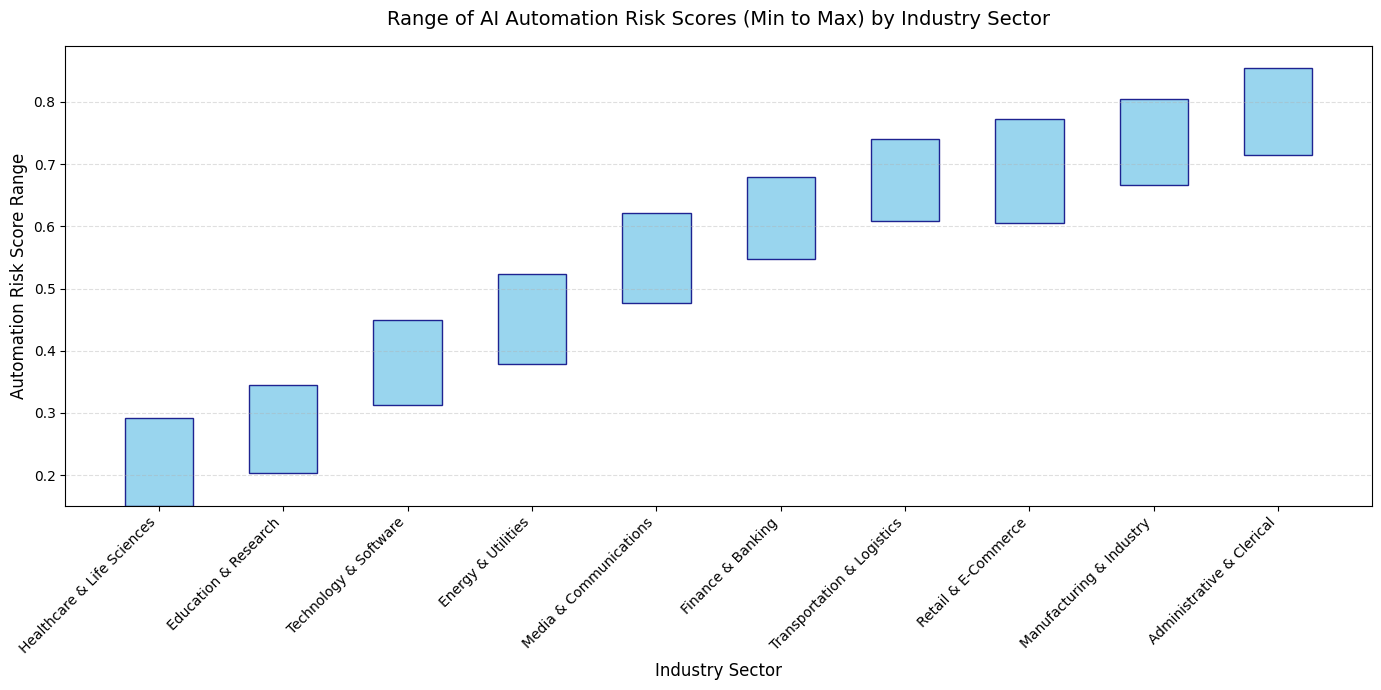

In [ ]:


# 1. Calculate the minimum and maximum values (the range) per industry sector
range_data = df.groupby('industry_sector')['sector_automation_risk_score'].agg(['min', 'max']).reset_index()

# Calculate the height of each column (the span between min and max)
range_data['span'] = range_data['max'] - range_data['min']

# Sort the data for a clean visual progression
range_data = range_data.sort_values('max')

# 2. Plotting the Range Column Chart
plt.figure(figsize=(14, 7))

# Use plt.bar with the 'bottom' parameter to float the columns
plt.bar(
    range_data['industry_sector'],
    range_data['span'],
    bottom=range_data['min'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.85,
    width=0.55
)

# 3. Formatting the layout
plt.title('Range of AI Automation Risk Scores (Min to Max) by Industry Sector', fontsize=14, pad=15)
plt.xlabel('Industry Sector', fontsize=12)
plt.ylabel('Automation Risk Score Range', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

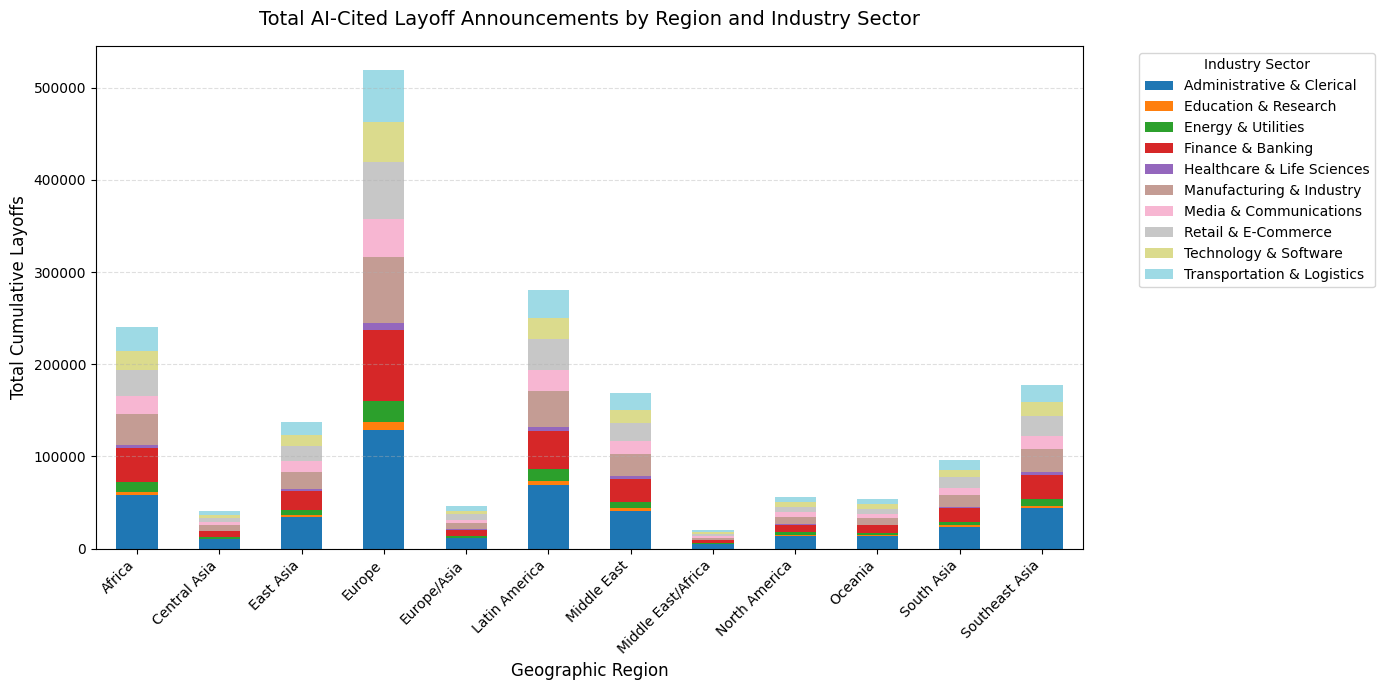

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a pivot table combining Region (Rows), Industry Sector (Columns), and Total Layoffs (Values)
stacked_data = df.pivot_table(
    index='region',
    columns='industry_sector',
    values='ai_cited_layoff_announcements',
    aggfunc='sum'
).fillna(0)

# 2. Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))
stacked_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

# Formatting the layout
plt.title('Total AI-Cited Layoff Announcements by Region and Industry Sector', fontsize=14, pad=15)
plt.xlabel('Geographic Region', fontsize=12)
plt.ylabel('Total Cumulative Layoffs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Place the legend outside so it doesn't mask the bars
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

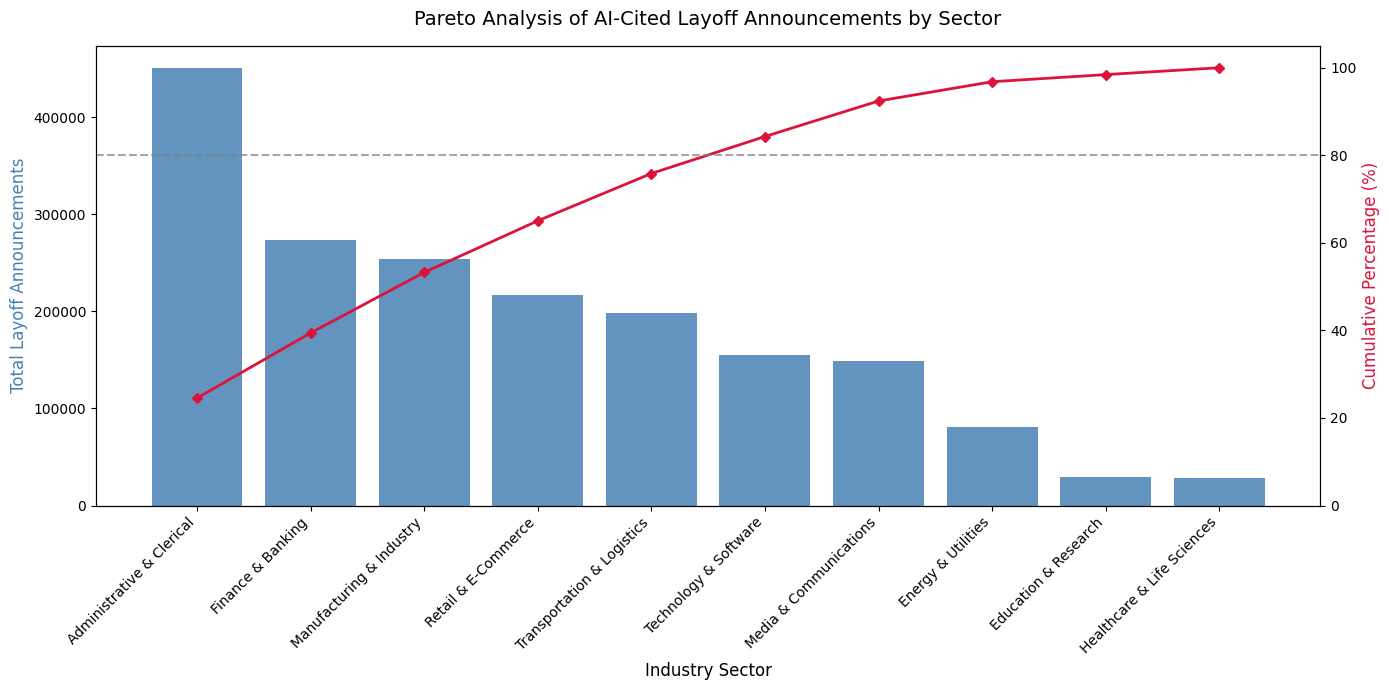

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aggregate and sort your data in descending order
pareto_data = df.groupby('industry_sector')['ai_cited_layoff_announcements'].sum().reset_index()
pareto_data = pareto_data.sort_values(by='ai_cited_layoff_announcements', ascending=False)

# 2. Calculate cumulative percentage
total_layoffs = pareto_data['ai_cited_layoff_announcements'].sum()
pareto_data['cum_percentage'] = (pareto_data['ai_cited_layoff_announcements'].cumsum() / total_layoffs) * 100

# 3. Create the plot structure
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the bars (Left Axis)
ax1.bar(pareto_data['industry_sector'], pareto_data['ai_cited_layoff_announcements'], color='steelblue', alpha=0.85)
ax1.set_ylabel('Total Layoff Announcements', color='steelblue', fontsize=12)
ax1.set_xlabel('Industry Sector', fontsize=12)
# Set ticks explicitly before setting tick labels to avoid the UserWarning
ax1.set_xticks(range(len(pareto_data['industry_sector'])))
ax1.set_xticklabels(pareto_data['industry_sector'], rotation=45, ha='right')

# Create a twin axis for the cumulative percentage line (Right Axis)
ax2 = ax1.twinx()
ax2.plot(pareto_data['industry_sector'], pareto_data['cum_percentage'], color='crimson', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='crimson', fontsize=12)
ax2.set_ylim(0, 105)

# Add a dashed line at the crucial 80% mark to pinpoint the vital few
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)

plt.title('Pareto Analysis of AI-Cited Layoff Announcements by Sector', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

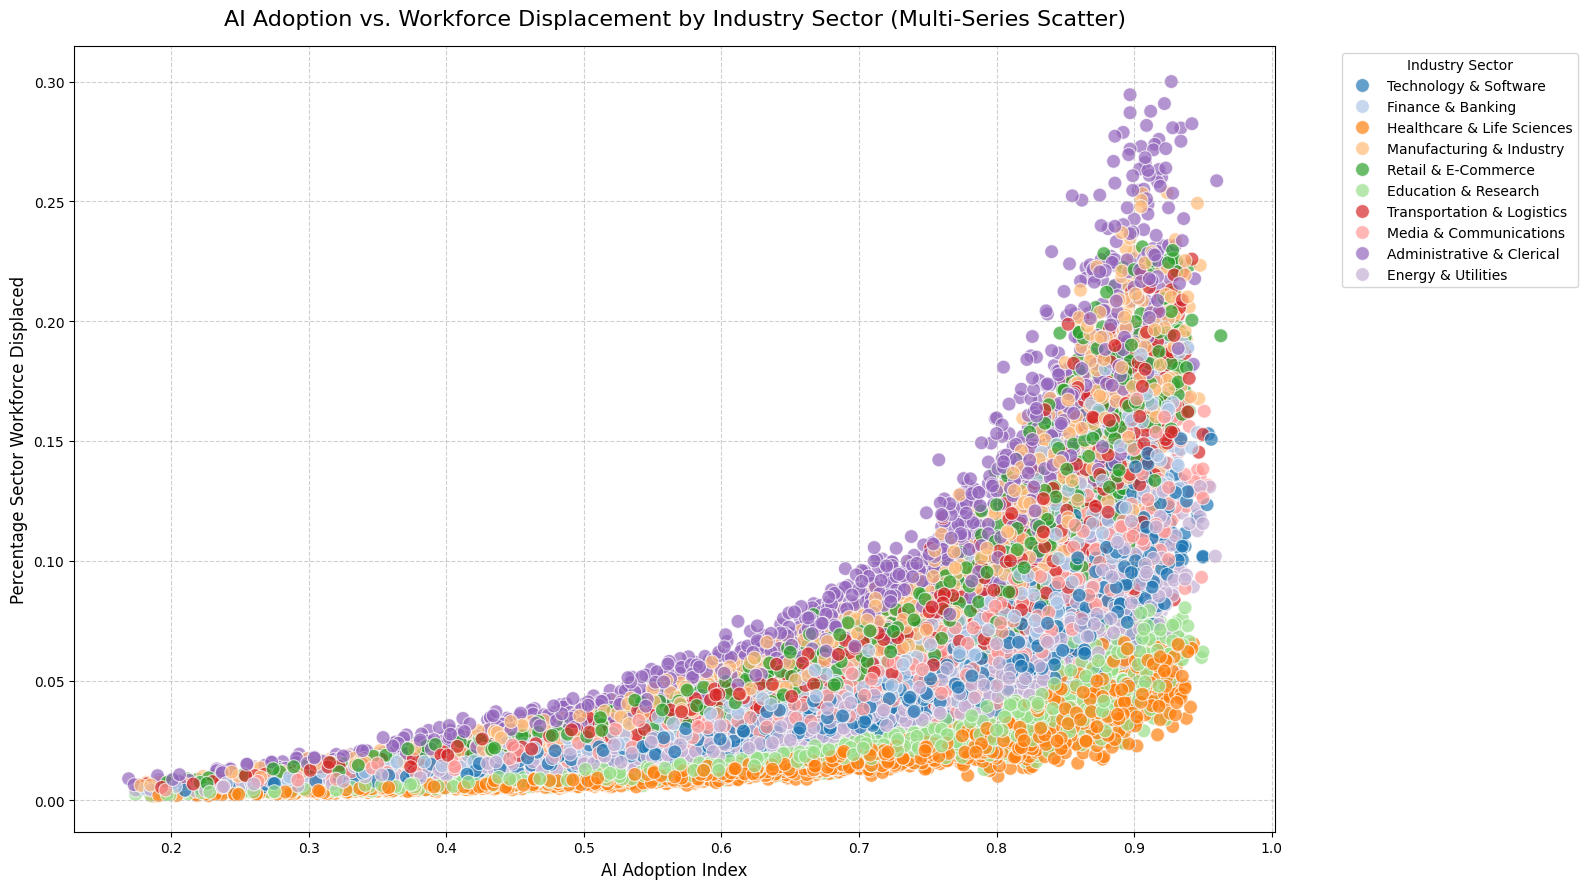

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=df,
    x='ai_adoption_index',
    y='pct_sector_workforce_displaced',
    hue='industry_sector', # Differentiates series by industry sector
    s=100, # Size of the points
    alpha=0.7,
    palette='tab20' # Use a distinct color palette for sectors
)

plt.title('AI Adoption vs. Workforce Displacement by Industry Sector (Multi-Series Scatter)', fontsize=16, pad=15)
plt.xlabel('AI Adoption Index', fontsize=12)
plt.ylabel('Percentage Sector Workforce Displaced', fontsize=12)
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
'''
seaborn fundamentals
'''

'\nseaborn fundamentals\n'

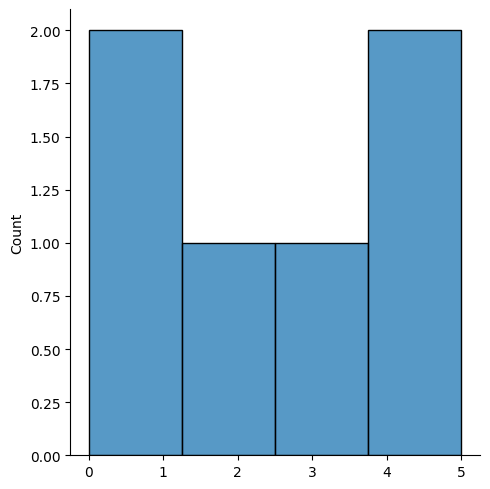

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot([0, 1, 2, 3, 4, 5])

plt.show()
#histogram in seaborn


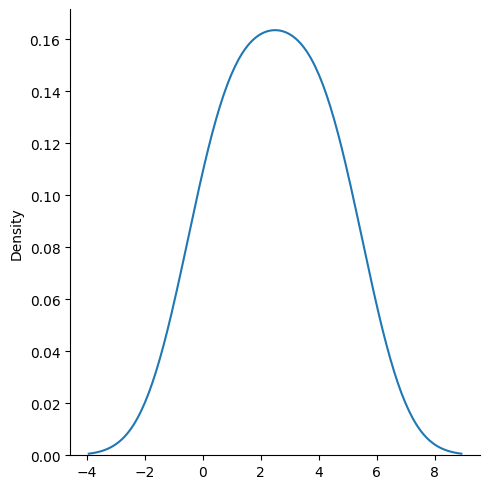

In [ ]:

sns.displot([0, 1, 2, 3, 4, 5], kind="kde")

plt.show()
#displot without histogram is a curve

/tmp/ipykernel_5007/4167026574.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x)


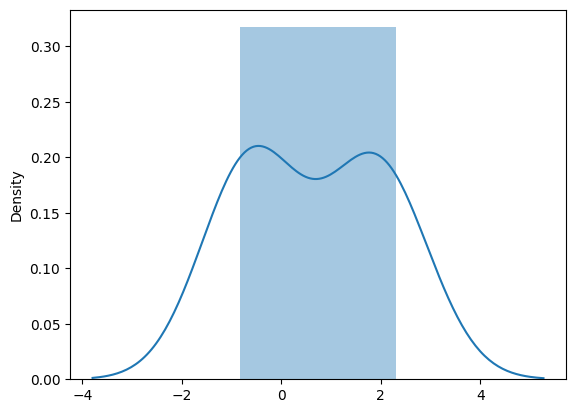

In [ ]:
from numpy import random

x = random.normal(size=(2, 3))

sns.distplot(x)
plt.show()

/tmp/ipykernel_5007/728350735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


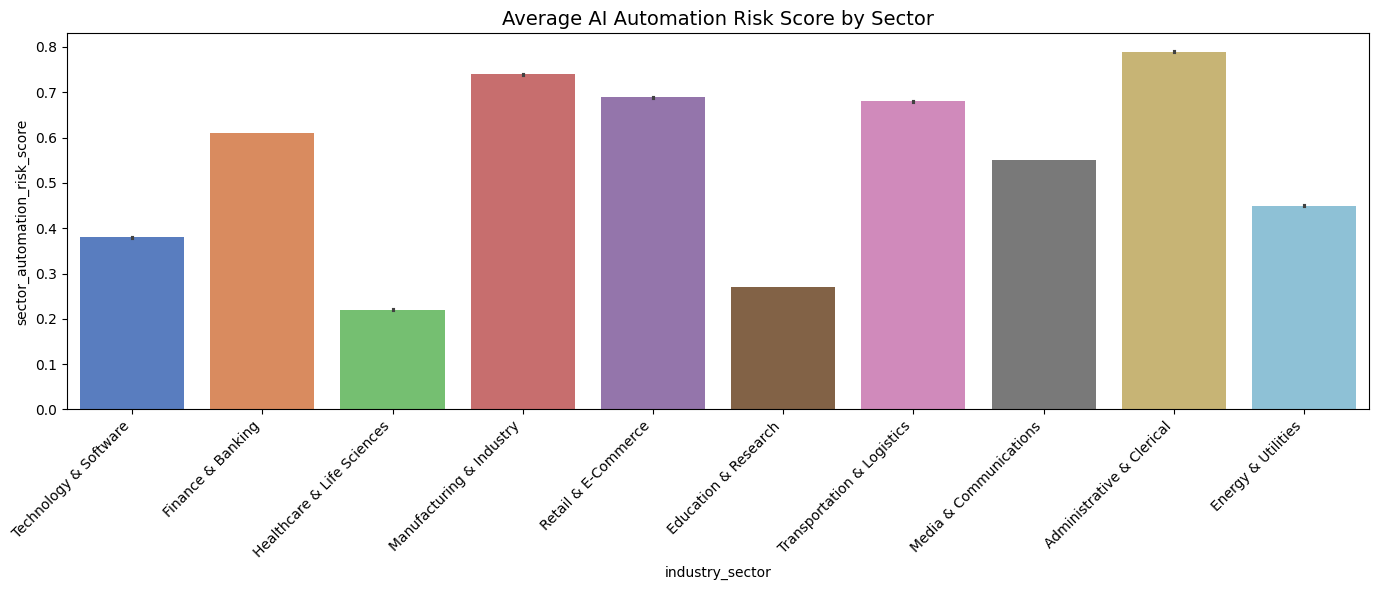

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plots the average automation risk score for each industry sector
sns.barplot(
    data=df,
    x='industry_sector',
    y='sector_automation_risk_score',
    palette='muted'
)

plt.title('Average AI Automation Risk Score by Sector', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5007/433704133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


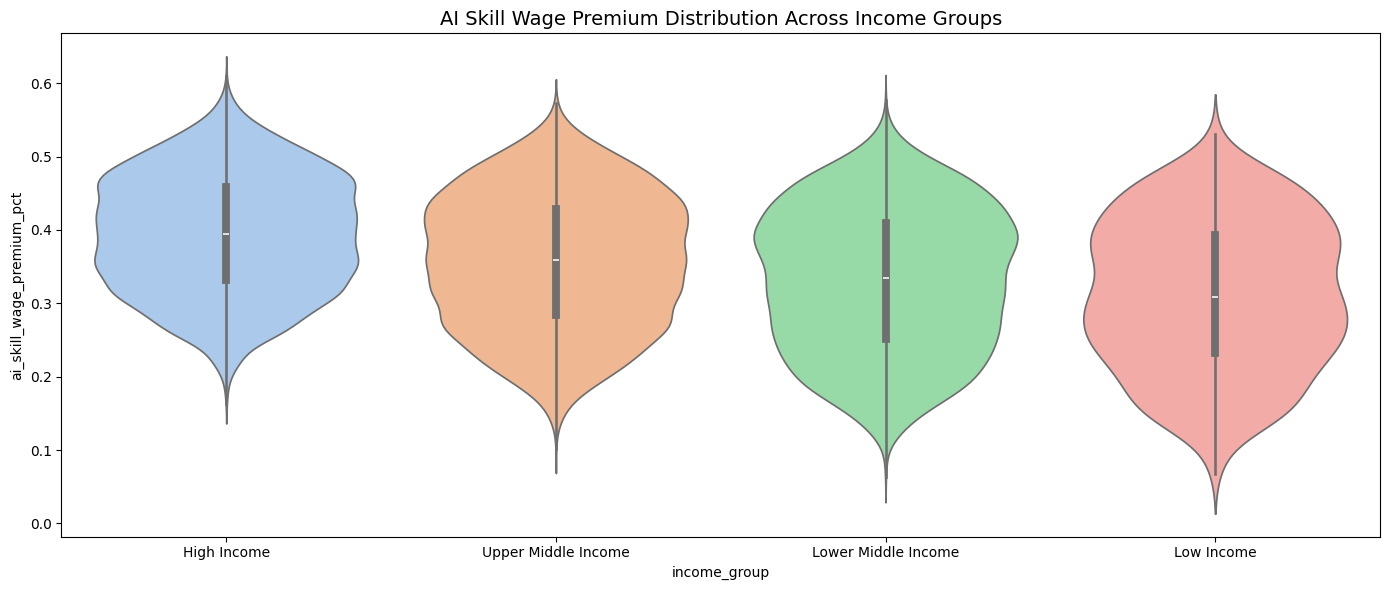

In [36]:
plt.figure(figsize=(14, 6))

# Visualizes the density distribution of wage premiums across different income groups
sns.violinplot(
    data=df,
    x='income_group',
    y='ai_skill_wage_premium_pct',
    palette='pastel'
)

plt.title('AI Skill Wage Premium Distribution Across Income Groups', fontsize=14)
plt.tight_layout()
plt.show()

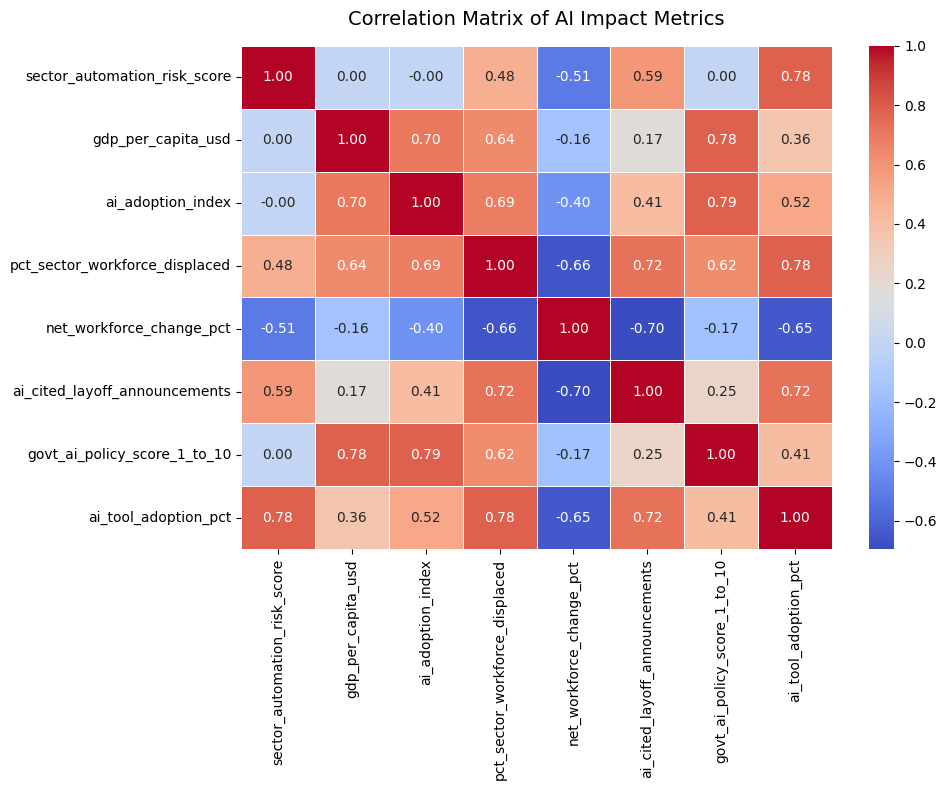

In [37]:
plt.figure(figsize=(10, 8))

# 1. Isolate the numerical metrics you want to check
numerical_cols = [
    'sector_automation_risk_score', 'gdp_per_capita_usd',
    'ai_adoption_index', 'pct_sector_workforce_displaced',
    'net_workforce_change_pct', 'ai_cited_layoff_announcements',
    'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct'
]

# 2. Compute the Pearson correlation matrix
corr_matrix = df[numerical_cols].corr()

# 3. Plot the matrix
sns.heatmap(
    corr_matrix,
    annot=True,             # Overlays the exact correlation number on the cell
    cmap='coolwarm',        # Red indicates positive correlation, blue indicates negative
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of AI Impact Metrics', fontsize=14, pad=15)
plt.tight_layout()
plt.show()